In [22]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst

pd.options.mode.use_inf_as_na = True

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_16648\2693178358.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [23]:
import os
import pandas as pd


def data_to_dataframe(pathinfo, y_col='Y (cm)', x_col='X (cm)', speed_col='SPEED#wcentroid (cm/s)', vy_col='VY (cm/s)', frame_col='frame'):
    """
    Reads CSV files from a specified directory tree, extracts specific columns, and compiles them into a single pandas DataFrame.

    This function traverses the directory tree starting at `pathinfo`, identifies CSV files with "Trial" in their filenames,
    and extracts specific columns. It combines these extracted columns into a single DataFrame with additional metadata 
    about the trial, condition, genotype, starvation, collective behavior, and concentration.

    Parameters:
    -----------
    pathinfo : str
        The root directory from which to start searching for CSV files.
    y_col : str, optional
        Column name for Y coordinates, default is 'Y (cm)'.
    x_col : str, optional
        Column name for X coordinates, default is 'X (cm)'.
    speed_col : str, optional
        Column name for speed, default is 'SPEED#wcentroid (cm/s)'.
    vy_col : str, optional
        Column name for Y velocity, default is 'VY (cm/s)'.
    frame_col : str, optional
        Column name for frame, default is 'frame'.

    Returns:
    --------
    pandas.DataFrame
        A DataFrame containing concatenated data from all relevant CSV files, with columns for Y, X, Speed, VY, Frame, Trial, Condition,
        Genotype, Starvation, Collective, Concentration, and Individual.

    Notes:
    ------
    - The function assumes that the CSV files contain the specified columns.
    - The 'Trial' and 'Condition' columns are derived from the directory structure where the CSV files are found.
    - The 'Genotype', 'Starvation', 'Collective', and 'Concentration' columns are extracted from the folder name pattern.
    - The 'Individual' column is simply the filename of the CSV file.
    - Uses os.path.join for cross-platform compatibility.

    Example:
    --------
    >>> df = data_to_dataframe("C:\\data\\experiments")
    >>> print(df.head())
    """
    
    df_files = []

    for root, dirs, files in os.walk(pathinfo):
        for f in files:
            if f.endswith(".csv"):
                file_path = os.path.join(root, f)
                try:
                    a = pd.read_csv(file_path)

                    # Extract metadata from the folder name
                    condition_folder = os.path.basename(os.path.dirname(root))
                    condition_parts = condition_folder.split()  # Assumes structure: 'Genotype Starvation Collective Concentration'
                    
                    if len(condition_parts) == 4:
                        genotype, starvation, collective, concentration = condition_parts
                    else:
                        genotype = starvation = collective = concentration = None  # Handle unexpected formats
                    
                    data = {
                        "Y": a[y_col],
                        "X": a[x_col],
                        "Speed": a[speed_col],
                        "VY": a[vy_col],
                        "Frame": a[frame_col],
                        "Trial": os.path.basename(root),
                        "Condition": condition_folder,
                        "Genotype": genotype,
                        "Starvation": starvation,
                        "Collective": collective,
                        "Concentration": concentration,
                        "Individual": f  # Filename as 'Individual'
                    }
                    df_files.append(pd.DataFrame(data))

                except KeyError as e:
                    print(f"Missing column in file {file_path}: {e}")
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return pd.concat(df_files, ignore_index=True) if df_files else pd.DataFrame()


def clean_dataframe(df):
    """
    Cleans the DataFrame by dropping rows with missing values and filtering 
    rows based on the 'Speed' column.

    This function removes rows with any missing values and retains only rows 
    where the 'Speed' value is between 0.5 and 2.0 (exclusive).

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame to be cleaned.

    Returns:
    --------
    pandas.DataFrame
        The cleaned DataFrame with no missing values and 'Speed' values 
        between 0.5 and 2.0.
    
    Example:
    --------
    >>> df = data_to_dataframe("C:\\data\\experiments")
    >>> clean_df = clean_dataframe(df)
    >>> print(clean_df.head())
    """

    df_cleaned = df.dropna()
    df_cleaned = df_cleaned[df_cleaned["Speed"].between(0.5, 2.0, inclusive='neither')]
    return df_cleaned

def calculate_distance_from_fixed_point(df):
    """
    Calculates distance from a fixed point ('X_1', 'Y_1') to each row's ('X', 'Y') coordinates in the DataFrame.

    This function iterates over each row in the input DataFrame and calculates the Euclidean distance 
    from a fixed point ('X_1', 'Y_1') to each row's ('X', 'Y') coordinates.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing 'X', 'Y', 'Frame', 'Trial', and 'Condition' columns.

    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional column 'Distance' appended to the input DataFrame.

    Example:
    --------
    >>> df = pd.DataFrame({
    >>>     'X': [1, 2, 3],
    >>>     'Y': [4, 5, 6],
    >>>     'Frame': [1, 2, 3],
    >>>     'Trial': ['Trial1', 'Trial1', 'Trial2'],
    >>>     'Condition': ['Condition1', 'Condition1', 'Condition2']
    >>> })
    >>> df_processed = calculate_distance_from_fixed_point(df)
    >>> print(df_processed.head())
    """

    # Fixed point coordinates
    x_1 = 14
    y_1 = 2

    # Calculate distance for each row
    x_1, y_1 = 14, 2  # Fixed reference point

    # Handle NaN values before calculations
    df = df.copy()  # Avoid modifying original DataFrame
    df['Distance'] = np.where(df[['X', 'Y']].isnull().any(axis=1), np.nan,
                              np.hypot(df['X'] - x_1, df['Y'] - y_1))

    return df

import pandas as pd

def categorize_values(df: pd.DataFrame, column: str, value: float, width: float) -> pd.DataFrame:
    """
    Categorizes the values in the specified column of the DataFrame and adds the result
    as a new column called 'Preference Index'.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The column name to analyze.
        value (float): The reference value for comparison.
        width (float): The width of the interval around the reference value.

    Returns:
        pd.DataFrame: The DataFrame with a new column 'Preference Index' indicating
                      1 if value is greater than value+width,
                      0 if between value+width and value-width,
                      -1 if less than value-width.
    """
    df['Preference Index'] = df[column].apply(lambda x: 1 if x > value + width else 
                                                    0 if value - width <= x <= value + width else 
                                                   -1)
    return df

# Example usage:
# df = pd.DataFrame({'column_name': [1, 5, 7, 10]})
# df = categorize_values(df, 'column_name', 5, 2)
# print(df)

In [24]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = data_to_dataframe(filepath)

In [25]:
primary_df = calculate_distance_from_fixed_point(primary_df)

In [26]:
primary_df = categorize_values(primary_df, 'X', 14, 1.5)

In [27]:
import pandas as pd

def interpolate_missing_values(df):
    """
    Interpolates missing ('NaN') values for 'X' and 'Y' columns within each unique 
    combination of 'Trial' and 'Condition'. This will fill in the gaps in the trajectories 
    for each Trial within each Condition.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing 'X', 'Y', 'Trial', and 'Condition' columns.
    
    Returns:
        pd.DataFrame: A DataFrame with missing values in 'X' and 'Y' interpolated within each 'Trial' and 'Condition'.
    """
    # Ensure the necessary columns exist
    if not {'X', 'Y', 'Trial', 'Condition'}.issubset(df.columns):
        raise ValueError("DataFrame must contain 'X', 'Y', 'Trial', and 'Condition' columns.")
    
    # Create a copy to avoid modifying the original DataFrame
    df_copy = df.copy()

    # Ensure 'Trial' is treated as a string for correct grouping
    df_copy['Trial'] = df_copy['Trial'].astype(str)

    # Interpolate missing values for X and Y within each group defined by 'Trial' and 'Condition'
    df_copy['X'] = df_copy.groupby(['Trial', 'Condition'])['X'].transform(lambda group: group.interpolate(method='linear', limit_direction='both'))
    df_copy['Y'] = df_copy.groupby(['Trial', 'Condition'])['Y'].transform(lambda group: group.interpolate(method='linear', limit_direction='both'))

    # Return the DataFrame with interpolated values
    return df_copy


In [28]:
# Apply function
primary_df_interp = interpolate_missing_values(primary_df)

# Debugging output
print(primary_df_interp[['X', 'Y']].isna().sum())  # Should be 0 if interpolation worked

X    0
Y    0
dtype: int64


In [29]:
rows_with_nan = primary_df_interp.isnull().any(axis=1).sum()
print(f"Number of rows with NaN values: {rows_with_nan}")

Number of rows with NaN values: 290670


In [30]:
primary_df_interp_WT = primary_df_interp[primary_df_interp['Genotype'] == 'WT']

In [31]:
primary_df_interp_early = primary_df_interp_WT[(primary_df_interp_WT['Frame'] > 0) & (primary_df_interp_WT['Frame'] < 300)]
primary_df_interp_mid = primary_df_interp_WT[(primary_df_interp_WT['Frame'] > 300) & (primary_df_interp_WT['Frame'] < 600)]
primary_df_interp_late = primary_df_interp_WT[(primary_df_interp_WT['Frame'] > 600) & (primary_df_interp_WT['Frame'] < 900)]

In [32]:
primary_df_interp_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'Trh')]

In [33]:
primary_df_interp_early_Trh = primary_df_interp_Trh[(primary_df_interp_Trh['Frame'] > 0) & (primary_df_interp_Trh['Frame'] < 300)]
primary_df_interp_mid_Trh = primary_df_interp_Trh[(primary_df_interp_Trh['Frame'] > 300) & (primary_df_interp_Trh['Frame'] < 600)]
primary_df_interp_late_Trh = primary_df_interp_Trh[(primary_df_interp_Trh['Frame'] > 600) & (primary_df_interp_Trh['Frame'] < 900)]

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def quantify_trajectory_zone_proportions(dataframe):
    """
    Quantifies the proportion of points in three dynamically defined zones along the y-axis 
    and visualizes them in a boxplot for all conditions in the dataframe.
    
    Parameters:
        dataframe (pd.DataFrame): The input dataframe containing trajectory data.
    """
    # Get min/max y-values to dynamically set the zones
    y_min, y_max = dataframe['Y'].min(), dataframe['Y'].max()
    y_range = (y_max - y_min) / 3  # Divide into 3 equal zones
    y_bounds = [y_min + y_range, y_min + 2 * y_range]  # Compute boundaries

    # Initialize storage
    zone_counts = []

    # Process each condition and trial
    for condition in dataframe['Condition'].unique():
        df_condition = dataframe[dataframe['Condition'] == condition]
        
        for trial in df_condition['Trial'].unique():
            df_trial = df_condition[df_condition['Trial'] == trial]
            total_points = len(df_trial)  # Total points in trial
            
            # Avoid division by zero (in case a trial has no data)
            if total_points == 0:
                continue
            
            # Count points in each zone
            count_zone_1 = np.sum(df_trial['Y'] < y_bounds[0])  # Bottom zone
            count_zone_2 = np.sum((df_trial['Y'] >= y_bounds[0]) & (df_trial['Y'] < y_bounds[1]))  # Middle zone
            count_zone_3 = np.sum(df_trial['Y'] >= y_bounds[1])  # Top zone
            
            # Convert counts to proportions
            zone_counts.append({'Condition': condition, 'Trial': trial, 'Zone': 'Zone 1', 'Proportion': count_zone_1 / total_points})
            zone_counts.append({'Condition': condition, 'Trial': trial, 'Zone': 'Zone 2', 'Proportion': count_zone_2 / total_points})
            zone_counts.append({'Condition': condition, 'Trial': trial, 'Zone': 'Zone 3', 'Proportion': count_zone_3 / total_points})

    # Convert to DataFrame
    df_zones = pd.DataFrame(zone_counts)

    # Plot boxplot with stripplot overlay
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Zone', y='Proportion', hue='Condition', data=df_zones, palette='pastel', showfliers=False)
    sns.stripplot(x='Zone', y='Proportion', hue='Condition', data=df_zones, 
                  dodge=True, color='black', size=6, alpha=0.7, jitter=True, legend=False)

    # Labels and title
    plt.ylabel("Proportion of Points in Zone")
    plt.title("Zone-wise Proportion of Trajectories")
    plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_zone_1_over_time(dataframe):
    """
    Plots the mean proportion of points in Zone 1 over time for each condition.
    
    Parameters:
        dataframe (pd.DataFrame): The input dataframe containing trajectory data.
    """
    # Get min/max y-values to define the zones
    y_min, y_max = dataframe['Y'].min(), dataframe['Y'].max()
    y_range = (y_max - y_min) / 3  # Divide into 3 equal zones
    y_bound = y_min + y_range  # Upper boundary of Zone 1

    # Initialize storage for frame-wise zone proportions
    frame_data = []

    # Process each condition, trial, and frame
    for condition in dataframe['Condition'].unique():
        df_condition = dataframe[dataframe['Condition'] == condition]

        for trial in df_condition['Trial'].unique():
            df_trial = df_condition[df_condition['Trial'] == trial]

            for frame in df_trial['Frame'].unique():
                df_frame = df_trial[df_trial['Frame'] == frame]
                total_points = len(df_frame)  # Total points in this frame
                
                if total_points == 0:
                    continue  # Avoid division by zero

                # Count points in Zone 1 (bottom zone)
                count_zone_1 = np.sum(df_frame['Y'] < y_bound)

                # Store proportion
                frame_data.append({
                    'Condition': condition, 
                    'Frame': frame, 
                    'Proportion': count_zone_1 / total_points
                })

    # Convert to DataFrame
    df_frames = pd.DataFrame(frame_data)

    # Plot mean proportion over time for each condition (without CI)
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Frame', y='Proportion', hue='Condition', data=df_frames, 
                 estimator='mean', palette='pastel', lw=2)  # `lw=2` for thicker lines

    # Labels and title
    plt.ylabel("Mean Proportion in Zone 1")
    plt.xlabel("Frame")
    plt.title("Mean Proportion of Points in Zone 1 Over Time")
    plt.legend(title="Condition")
    plt.show()


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_zone_means(dataframe):
    """
    Plots the mean proportion of points in each zone and connects them with lines within each condition.
    
    Parameters:
        dataframe (pd.DataFrame): The input dataframe containing trajectory data.
        Assumes a column 'Starvation' with values '5h' or 'Fed' exists.
    """
    # Get min/max y-values to define the zones
    y_min, y_max = dataframe['Y'].min(), dataframe['Y'].max()
    y_range = (y_max - y_min) / 3  # Divide into 3 equal zones
    y_bounds = [y_min + y_range, y_min + 2 * y_range]  # Compute boundaries

    # Initialize storage for mean values
    zone_means = []

    # Compute means for each condition
    for condition in dataframe['Condition'].unique():
        df_condition = dataframe[dataframe['Condition'] == condition]
        starvation_status = df_condition['Starvation'].iloc[0]  # Get starvation status

        # Compute mean proportions for each zone
        mean_zone_1 = np.mean(df_condition['Y'] < y_bounds[0])
        mean_zone_2 = np.mean((df_condition['Y'] >= y_bounds[0]) & (df_condition['Y'] < y_bounds[1]))
        mean_zone_3 = np.mean(df_condition['Y'] >= y_bounds[1])

        zone_means.append({'Condition': condition, 'Starvation': starvation_status, 'Zone': 'Zone 1', 'Mean Proportion': mean_zone_1})
        zone_means.append({'Condition': condition, 'Starvation': starvation_status, 'Zone': 'Zone 2', 'Mean Proportion': mean_zone_2})
        zone_means.append({'Condition': condition, 'Starvation': starvation_status, 'Zone': 'Zone 3', 'Mean Proportion': mean_zone_3})

    # Convert to DataFrame
    df_means = pd.DataFrame(zone_means)

    # Create plot
    plt.figure(figsize=(8, 6))

    # Get unique conditions and categorize by starvation status
    conditions = df_means['Condition'].unique()
    starvation_conditions = df_means['Starvation'].unique()

    # Define color palettes
    red_shades = sns.color_palette("Reds", sum(df_means['Starvation'] == '5h'))
    blue_shades = sns.color_palette("Blues", sum(df_means['Starvation'] == 'Fed'))

    # Assign colors to conditions
    color_mapping = {}
    red_idx, blue_idx = 0, 0  # Track color indices for red and blue

    for condition in conditions:
        starvation_status = df_means[df_means['Condition'] == condition]['Starvation'].iloc[0]
        
        if starvation_status == '5h':  # Assign shades of red
            color_mapping[condition] = red_shades[red_idx]
            red_idx += 1
        else:  # Assign shades of blue
            color_mapping[condition] = blue_shades[blue_idx]
            blue_idx += 1

    # Plot means and connect them with lines
    for condition in conditions:
        df_cond = df_means[df_means['Condition'] == condition]
        
        plt.plot(df_cond['Zone'], df_cond['Mean Proportion'], marker='o', markersize=8, 
                 linestyle='-', linewidth=2, color=color_mapping[condition], label=condition)

    # Labels and title
    plt.ylabel("Mean Proportion of Points")
    plt.xlabel("Zone")
    plt.title("Mean Zone Proportions per Condition")
    plt.ylim(0, 1)  # Set y-axis from 0 to 1
    plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_zone_means_subplot(dataframes, concentrations, titles):
    """
    Creates a 3x3 subplot panel of mean zone proportions for different time points and concentrations.
    
    Parameters:
        dataframes (list): List of DataFrames [early, mid, late].
        concentrations (list): List of concentrations ['10-3', '10-4', '10-5'].
        titles (list): Titles for each row (time points: early, mid, late).
    """
    fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharey=True, sharex=True)
    
    # **Improved Bright Color Palettes**
    red_shades = sns.color_palette("Reds", 3)  
    blue_shades = sns.color_palette("Blues", 3)  

    # **Clamp values between 0 and 1 to avoid invalid colors**
    red_shades = [(min(r, 1), min(g, 1), min(b, 1)) for r, g, b in red_shades]
    blue_shades = [(min(r*0.8, 1), min(g*0.9, 1), min(b*1.1, 1)) for r, g, b in blue_shades]  # Ensure valid colors

    for row_idx, (df, title) in enumerate(zip(dataframes, titles)):
        for col_idx, conc in enumerate(concentrations):
            ax = axes[row_idx, col_idx]
            
            df_filtered = df[df['Concentration'] == conc]

            if df_filtered.empty:
                ax.set_visible(False)
                continue

            y_min, y_max = df_filtered['Y'].min(), df_filtered['Y'].max()
            y_range = (y_max - y_min) / 3  
            y_bounds = [y_min + y_range, y_min + 2 * y_range]  

            zone_means = []

            for condition in df_filtered['Condition'].unique():
                df_condition = df_filtered[df_filtered['Condition'] == condition]
                starvation_status = df_condition['Starvation'].iloc[0]  

                mean_zone_1 = np.mean(df_condition['Y'] < y_bounds[0])
                mean_zone_2 = np.mean((df_condition['Y'] >= y_bounds[0]) & (df_condition['Y'] < y_bounds[1]))
                mean_zone_3 = np.mean(df_condition['Y'] >= y_bounds[1])

                zone_means.append({'Condition': condition, 'Starvation': starvation_status, 'Zone': 'Zone 1', 'Mean Proportion': mean_zone_1})
                zone_means.append({'Condition': condition, 'Starvation': starvation_status, 'Zone': 'Zone 2', 'Mean Proportion': mean_zone_2})
                zone_means.append({'Condition': condition, 'Starvation': starvation_status, 'Zone': 'Zone 3', 'Mean Proportion': mean_zone_3})

            df_means = pd.DataFrame(zone_means)

            color_mapping = {}
            red_idx, blue_idx = 0, 0  

            for condition in df_means['Condition'].unique():
                starvation_status = df_means[df_means['Condition'] == condition]['Starvation'].iloc[0]

                if starvation_status == '5h':  
                    color_mapping[condition] = red_shades[red_idx]
                    red_idx = (red_idx + 1) % len(red_shades)
                else:  
                    color_mapping[condition] = blue_shades[blue_idx]
                    blue_idx = (blue_idx + 1) % len(blue_shades)

            for condition in df_means['Condition'].unique():
                df_cond = df_means[df_means['Condition'] == condition]

                ax.plot(df_cond['Zone'], df_cond['Mean Proportion'], marker='o', markersize=6, 
                        linestyle='-', linewidth=4, color=color_mapping[condition], label=condition)

            ax.set_ylim(0, 1)
            if row_idx == 0:
                ax.set_title(f"Concentration: {conc}")
            if col_idx == 0:
                ax.set_ylabel(f"{title}\nMean Proportion")
            if row_idx == 2:
                ax.set_xlabel("Zone")

            if row_idx == 0 and col_idx == 0:
                ax.legend(title="Condition", loc='upper right', fontsize=10, frameon=True)

    plt.tight_layout()
    plt.show()

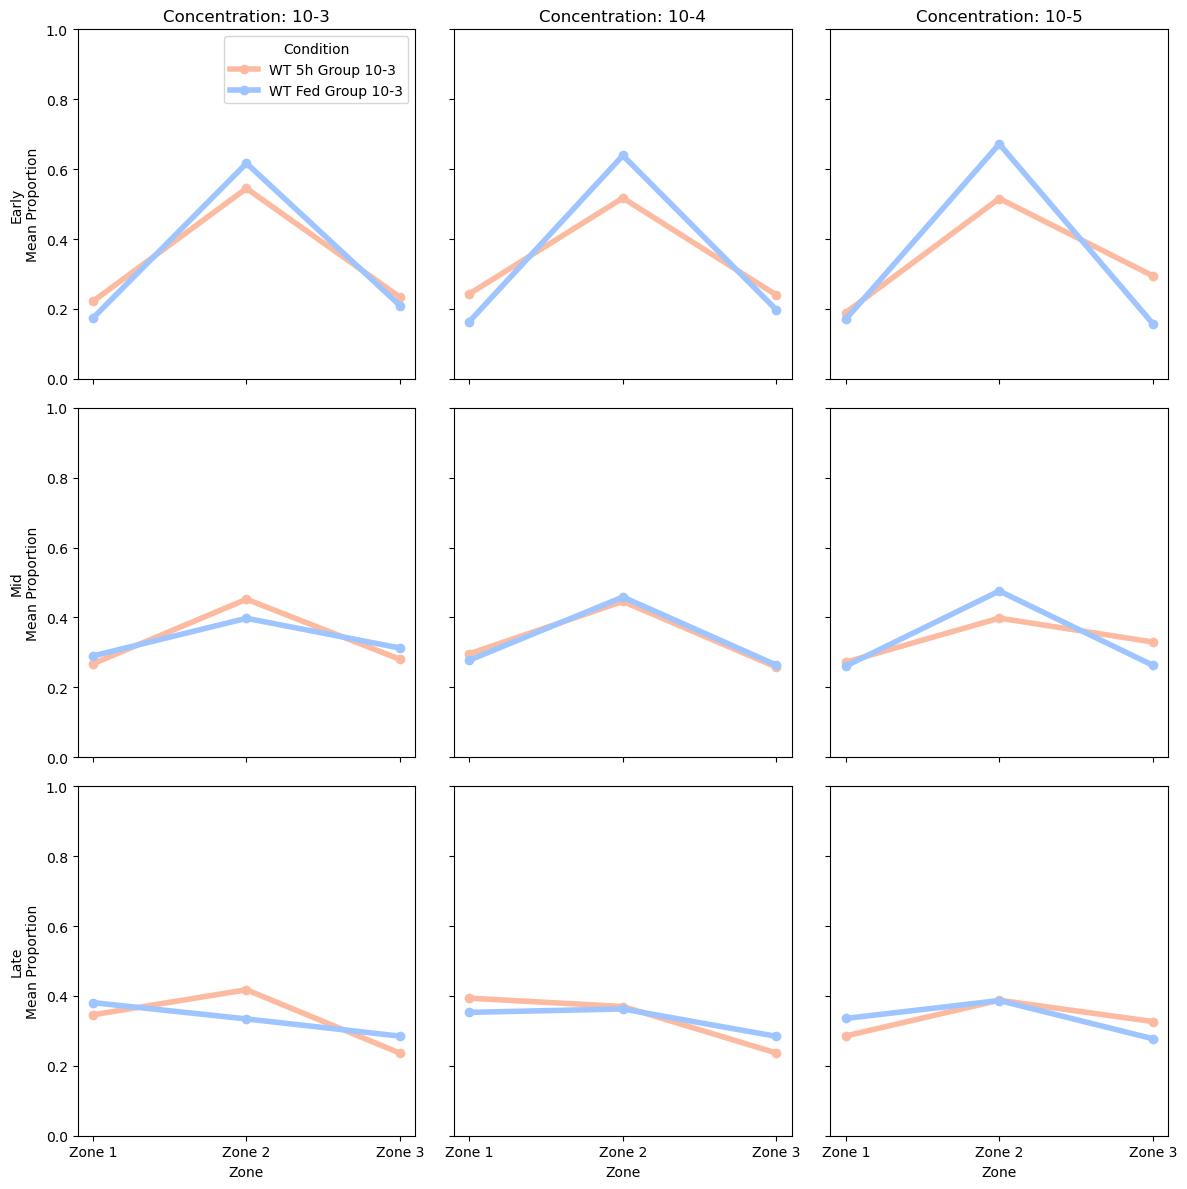

In [38]:
dataframes = [primary_df_interp_early, primary_df_interp_mid, primary_df_interp_late]
concentrations = ['10-3', '10-4', '10-5']
titles = ["Early", "Mid", "Late"]

plot_zone_means_subplot(dataframes, concentrations, titles)

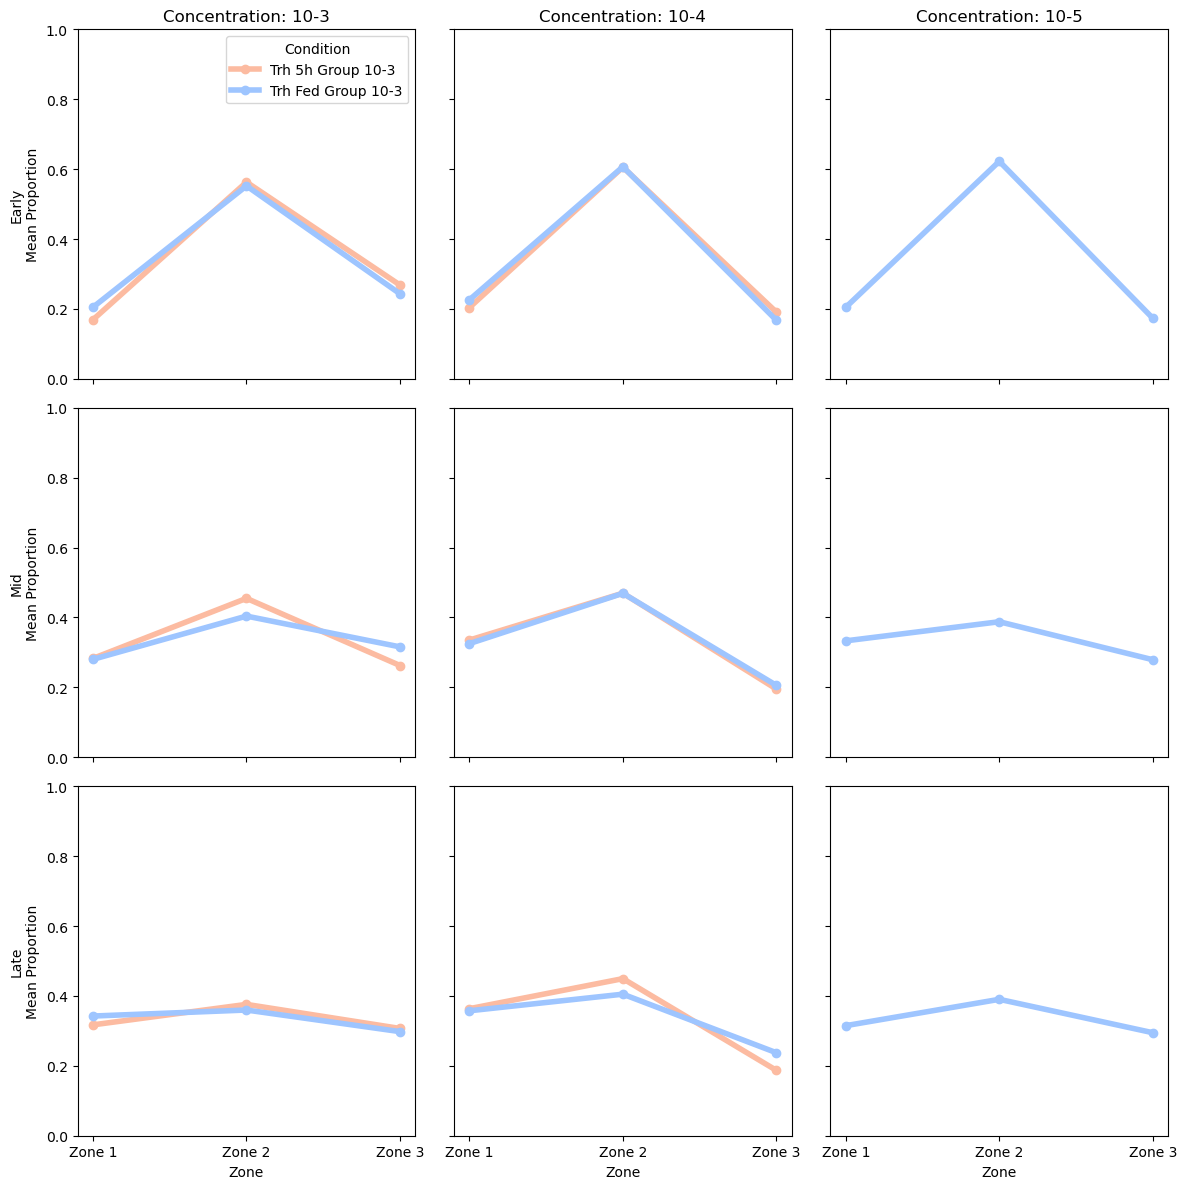

In [39]:
dataframes_Trh = [primary_df_interp_early_Trh, primary_df_interp_mid_Trh, primary_df_interp_late_Trh]
concentrations = ['10-3', '10-4', '10-5']
titles = ["Early", "Mid", "Late"]

plot_zone_means_subplot(dataframes_Trh, concentrations, titles)

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distance_by_condition_average(
    df,
    frame_column='Frame',
    distance_column='Distance',
    condition_column='Condition',
    trial_column='Trial',
    bin_size=100
):
    """
    Plots boxplots of 'Distance' averaged per 'Trial', binned by 'Frame' intervals, comparing different conditions.
    Displays all bins.

    Parameters:
        df (pd.DataFrame): The DataFrame containing 'Distance', 'Frame', 'Condition', and 'Trial' columns.
        frame_column (str): The column name representing the frame number.
        distance_column (str): The column name representing the pre-calculated distance.
        condition_column (str): The column name representing the condition for comparison.
        trial_column (str): The column representing individual trials.
        bin_size (int): The number of frames to group together in each bin for boxplots.
    """
    # Ensure the necessary columns exist
    required_columns = {frame_column, distance_column, condition_column, trial_column}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")
    
    # Add a column for the bin (Frame interval)
    df['Bin'] = (df[frame_column] // bin_size) * bin_size
    
    # Group by Bin, Condition, and Trial → Compute mean Distance per Trial
    df_avg = df.groupby(['Bin', condition_column, trial_column])[distance_column].mean().reset_index()
    
    # Get unique conditions and generate Viridis colors
    unique_conditions = df_avg[condition_column].nunique()
    viridis_palette = sns.color_palette("viridis", unique_conditions)

    # Plotting the boxplots for Distance within all bins and grouped by Condition
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column, palette=viridis_palette)
    sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column, 
                  dodge=True, color="black", alpha=0.6, jitter=True, legend=False)

    plt.title('Boxplots of Averaged Distance per Trial (All Bins) by Condition')
    plt.xlabel('Frame Interval')
    plt.ylabel('Average Distance per Trial to the Odour Source')
    plt.xticks(rotation=45)  # Rotate x labels for readability

    # Move the hue legend outside the plot
    plt.legend(title=condition_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


C:\Users\hpnhp\AppData\Local\Temp\ipykernel_16648\1134973444.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Bin'] = (df[frame_column] // bin_size) * bin_size
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_16648\1134973444.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column,


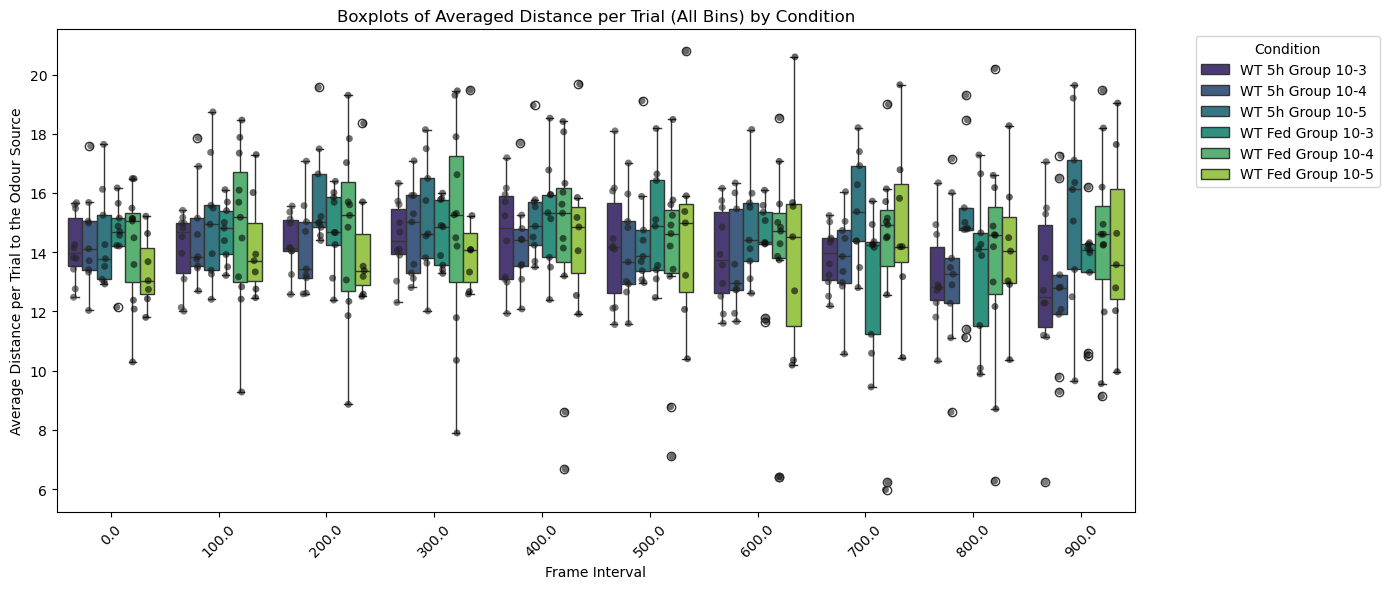

In [41]:
plot_distance_by_condition_average(primary_df_interp_WT)

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_16648\1134973444.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Bin'] = (df[frame_column] // bin_size) * bin_size
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_16648\1134973444.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_avg, x='Bin', y=distance_column, hue=condition_column,


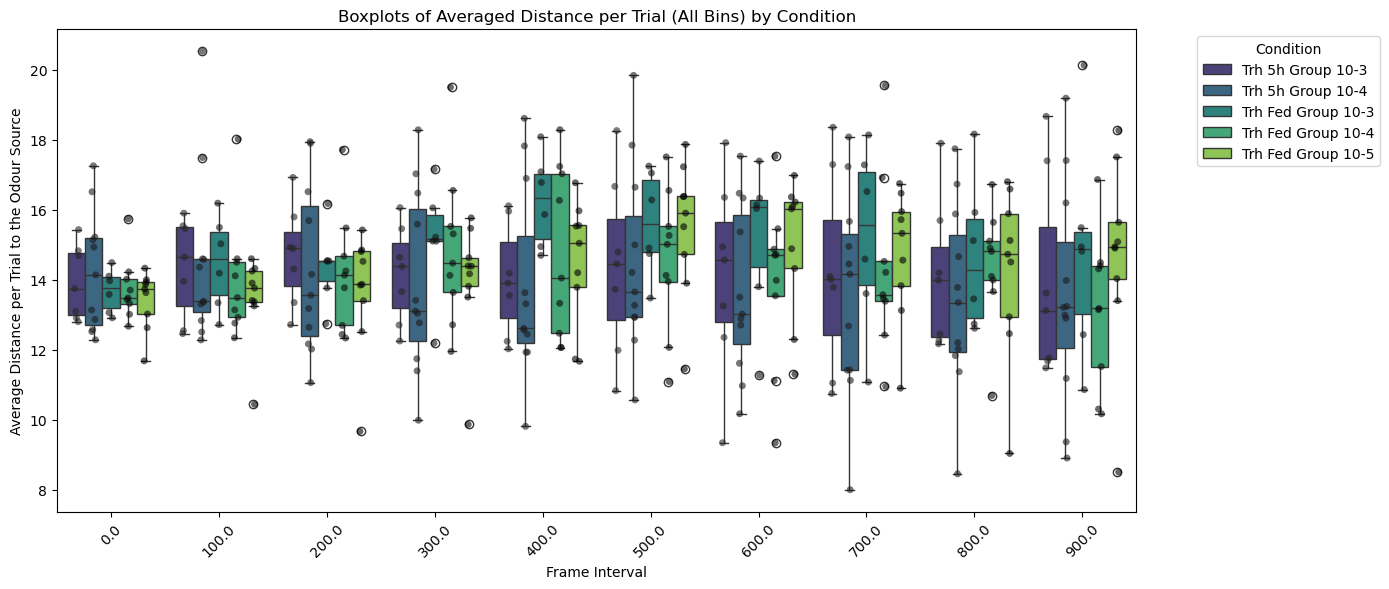

In [42]:
plot_distance_by_condition_average(primary_df_interp_Trh)